In [ ]:
#  Integration, Comparison

In [1]:
# Rebuild Dataset 

import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n = 500

neighborhood = rng.choice(['Downtown', 'Suburb', 'Rural'], size=n, p=[0.4, 0.4, 0.2])
house_style = rng.choice(['1Story', '2Story', 'Split'], size=n)
sqft = rng.normal(1800, 500, n).clip(500, 4000)
bedrooms = rng.integers(1, 6, n)
age = rng.integers(0, 80, n)
distance_to_city = rng.normal(15, 8, n).clip(0.5, 60)

neighborhood_premium = {'Downtown': 1.4, 'Suburb': 1.1, 'Rural': 0.8}
style_premium = {'1Story': 1.0, '2Story': 1.15, 'Split': 1.05}
base_price = (sqft * 120 + bedrooms * 8000 - age * 500 - distance_to_city * 900)
price = base_price * np.array([neighborhood_premium[v] for v in neighborhood]) \
              * np.array([style_premium[v] for v in house_style])
price = price + rng.normal(0, 15000, n)

df = pd.DataFrame({
    'neighborhood': neighborhood, 'house_style': house_style,
    'sqft': sqft, 'bedrooms': bedrooms, 'age': age,
    'distance_to_city': distance_to_city, 'price': price
})

outlier_idx = rng.choice(n, size=12, replace=False)
df.loc[outlier_idx[:6], 'sqft'] = rng.uniform(7000, 9000, 6)
df.loc[outlier_idx[6:], 'distance_to_city'] = rng.uniform(150, 200, 6)
mask = df.index.isin(outlier_idx[:6])
df.loc[mask, 'price'] = df.loc[mask, 'sqft'] * 120 + rng.normal(0, 15000, mask.sum())

df.head()


,neighborhood,house_style,sqft,bedrooms,age,distance_to_city,price
0,Suburb,Split,1751.910532,5,3,14.094653,299305.721767
1,Suburb,Split,2364.009429,4,58,6.898529,310949.443643
2,Rural,2Story,659.631077,1,39,16.012774,49193.167467
3,Suburb,Split,1051.680655,5,36,10.330557,160603.490086
4,Downtown,1Story,1338.556779,4,42,10.772591,225232.970754


In [2]:
# Baseline (Week 6 style)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

raw_numeric_cols = ['sqft', 'bedrooms', 'age', 'distance_to_city']

X_raw = df[raw_numeric_cols]
y_raw = df['price']

X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

baseline_model = RandomForestRegressor(random_state=42)
baseline_model.fit(X_train, y_train)
preds = baseline_model.predict(X_test)
stage1_rmse = mean_squared_error(y_test, preds) ** 0.5

print(f"Stage 1 - Baseline (single split, raw features): RMSE = {stage1_rmse:.2f}")


Stage 1 - Baseline (single split, raw features): RMSE = 64869.57


In [3]:
# CV-only

from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
model_default = RandomForestRegressor(random_state=42)

stage2_scores = -cross_val_score(model_default, X_raw, y_raw, cv=kf, scoring='neg_root_mean_squared_error')
stage2_mean, stage2_std = stage2_scores.mean(), stage2_scores.std()

print(f"Stage 2 - CV-only: Mean RMSE = {stage2_mean:.2f}  Std = {stage2_std:.2f}")


Stage 2 - CV-only: Mean RMSE = 63868.10  Std = 3564.55


In [4]:
# CV + Feature Engineering

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def cap_outliers(series, lower_q=0.01, upper_q=0.99):
    lower, upper = series.quantile(lower_q), series.quantile(upper_q)
    return series.clip(lower, upper)

df_eng = df.copy()
df_eng['sqft'] = cap_outliers(df_eng['sqft'])
df_eng['distance_to_city'] = cap_outliers(df_eng['distance_to_city'])
df_eng['sqft_per_bedroom'] = df_eng['sqft'] / df_eng['bedrooms']
df_eng['is_far_commute'] = (df_eng['distance_to_city'] > 25).astype(int)

numeric_cols = ['sqft', 'bedrooms', 'age', 'distance_to_city', 'sqft_per_bedroom', 'is_far_commute']
categorical_cols = ['neighborhood', 'house_style']

X_eng = df_eng[numeric_cols + categorical_cols]
y_eng = df_eng['price']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

pipeline_default = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

stage3_scores = -cross_val_score(pipeline_default, X_eng, y_eng, cv=kf, scoring='neg_root_mean_squared_error')
stage3_mean, stage3_std = stage3_scores.mean(), stage3_scores.std()

print(f"Stage 3 - CV + Feature Engineering: Mean RMSE = {stage3_mean:.2f}  Std = {stage3_std:.2f}")


Stage 3 - CV + Feature Engineering: Mean RMSE = 34531.26  Std = 11617.72


In [5]:
# CV + Feature Engineering + Tuning

pipeline_tuned = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ))
])

stage4_scores = -cross_val_score(pipeline_tuned, X_eng, y_eng, cv=kf, scoring='neg_root_mean_squared_error')
stage4_mean, stage4_std = stage4_scores.mean(), stage4_scores.std()

print(f"Stage 4 - CV + FeatureEng + Tuning: Mean RMSE = {stage4_mean:.2f}  Std = {stage4_std:.2f}")


Stage 4 - CV + FeatureEng + Tuning: Mean RMSE = 33676.60  Std = 10579.87


In [6]:
# Final Comparison Table

results = pd.DataFrame({
    'Stage': [
        '1. Baseline (Week 6, single split)',
        '2. CV-only',
        '3. CV + Feature Engineering',
        '4. CV + FeatureEng + Tuning'
    ],
    'RMSE (mean)': [stage1_rmse, stage2_mean, stage3_mean, stage4_mean],
    'Std across folds': [np.nan, stage2_std, stage3_std, stage4_std]
})
results['Improvement vs Stage 1'] = stage1_rmse - results['RMSE (mean)']
results['Improvement %'] = 100 * results['Improvement vs Stage 1'] / stage1_rmse

pd.set_option('display.float_format', lambda x: f'{x:.2f}')
results


,Stage,RMSE (mean),Std across folds,Improvement vs Stage 1,Improvement %
0,"1. Baseline (Week 6, single split)",64869.57,NaN,0.00,0.00
1,2. CV-only,63868.10,3564.55,1001.47,1.54
2,3. CV + Feature Engineering,34531.26,11617.72,30338.31,46.77
3,4. CV + FeatureEng + Tuning,33676.60,10579.87,31192.97,48.09


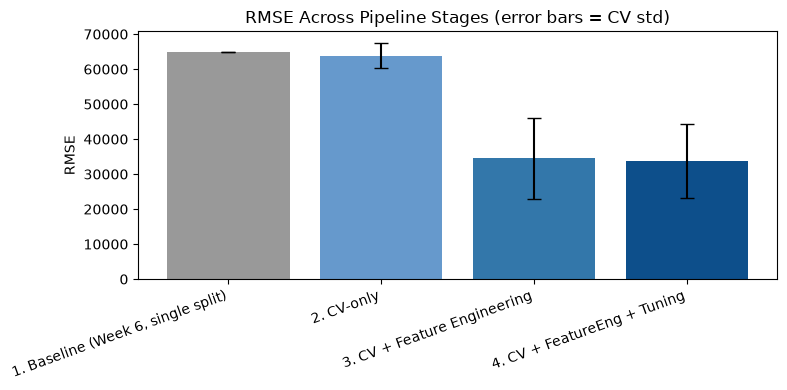

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,4))
stages = results['Stage']
means = results['RMSE (mean)']
stds = results['Std across folds'].fillna(0)

ax.bar(stages, means, yerr=stds, capsize=5, color=['#999', '#6699cc', '#3377aa', '#0d4f8b'])
ax.set_ylabel('RMSE')
ax.set_title('RMSE Across Pipeline Stages (error bars = CV std)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=100)
plt.show()
